# QLoRA-for-Automated-Paper-Review-Insights


## Introduction

The peer review process is a pillar of scientific publishing, ensuring that research papers meet standards of quality, rigor, and validity. However, the exponential growth of scientific publications has placed significant strain on traditional review systems, leading to longer review times, reviewer overload, and concerns about sustainability.

The goal of this study, in line with recent advances in LLM for automated reviews, is to understand whether fine tuning a LLM (Qwen3-1.7B) with QLoRa (Quantized Low Rank Adaptation) can help generating reviews similar to real ones, in order to at least replace some aspects of the review process.

### 1. Dependencies installations

In [1]:
!pip install transformers peft datasets accelerate evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [2]:
!pip install -U transformers accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.4 MB/s eta 0:00:00


In [4]:
!pip install openpyxl
!pip install rouge_score
!pip install bert_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7b4f1cbc956bbf4a63ee5b0fd0ff80f92475c986da053f32450c6a3d7d4bd33c
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.6 MB/s eta 0:00:00


In [5]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset, Dataset
import evaluate
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainerCallback
import openpyxl
from transformers import DataCollatorForLanguageModeling, BitsAndBytesConfig, EarlyStoppingCallback
from bitsandbytes.functional import dequantize_nf4
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import plotly.graph_objects as go
import plotly.io as pio
from rouge_score.rouge_scorer import RougeScorer
import random
import numpy as np
import evaluate
from bert_score import score as bert_score
import re
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data and Environment preparation

In [6]:
# Disable the tokenizers parallelism warning.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [7]:
# global seed for reproducibility
def set_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(77)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


The dataset used

In [9]:
# OpenReview 2018 dataset
file_path = "https://github.com/Seafoodair/Openreview/raw/master/ICLR2021-2022/data/2017.xlsx"

df = pd.read_excel(file_path, sheet_name = "Sheet3")

In [10]:
df.columns

Index(['auto_increase', 'id', 'title', 'submit_date', 'decision', 'Confidence',
       'rate1', 'rate', 'review', 'abstract_field', 'keyword_field',
       'Unnamed: 11'],
      dtype='object')

In [11]:
# Basic info about the dataframe
print("Shape of dataset:", df.shape)

print("\nColumns:", df.columns.tolist())
print("\nSample rows:")

display(df.head())

print("\nMissing values per column:")
print(df.isna().sum())


Shape of dataset: (4733, 12)

Columns: ['auto_increase', 'id', 'title', 'submit_date', 'decision', 'Confidence', 'rate1', 'rate', 'review', 'abstract_field', 'keyword_field', 'Unnamed: 11']

Sample rows:


,auto_increase,id,title,submit_date,decision,Confidence,rate1,rate,review,abstract_field,keyword_field,Unnamed: 11
0,12517,2082,$A^*$ sampling with probability matching | Ope...,28 Sep 2018 (modified: 21 Dec 2018),0,2: The reviewer is willing to defend the evalu...,NaN,6,"It seems a good paper, containing with intere...",Abstract:###Probabilistic methods often need t...,NaN,NaN
1,12518,2083,$A^*$ sampling with probability matching | Ope...,28 Sep 2018 (modified: 21 Dec 2018),0,5: The reviewer is absolutely certain that the...,NaN,3,This paper proposes an alternative search pro...,Abstract:###Probabilistic methods often need t...,NaN,NaN
2,14331,3896,$A^*$ sampling with probability matching | Ope...,28 Sep 2018 (modified: 21 Dec 2018),0,5: The reviewer is absolutely certain that the...,NaN,5,Summary: This paper introduces a probability ...,Abstract:###Probabilistic methods often need t...,NaN,NaN
3,11920,1485,(Unconstrained) Beam Search is Sensitive to La...,28 Sep 2018 (modified: 21 Dec 2018),0,5: The reviewer is absolutely certain that the...,NaN,5,This work does extensive experiments on three...,Abstract:###Beam search is the most popular in...,"Keywords:###beam search, sequence models, sear...",TL;DR:###Analysis of the performance degradati...
4,11921,1486,(Unconstrained) Beam Search is Sensitive to La...,28 Sep 2018 (modified: 21 Dec 2018),0,5: The reviewer is absolutely certain that the...,NaN,7,Pros: - The paper generalizes upon past obser...,Abstract:###Beam search is the most popular in...,"Keywords:###beam search, sequence models, sear...",TL;DR:###Analysis of the performance degradati...



Missing values per column:
auto_increase        0
id                   0
title                0
submit_date          9
decision             0
Confidence           0
rate1             4733
rate                 0
review               0
abstract_field       9
keyword_field      387
Unnamed: 11       1056
dtype: int64


In [12]:
# unique papers
if "title" in df.columns:
    print("\nUnique papers:", df['title'].nunique())
    print("Total reviews:", len(df))
    print("Avg reviews per paper:", len(df) / df['title'].nunique())


Unique papers: 1544
Total reviews: 4733
Avg reviews per paper: 3.0654145077720205


In [13]:
df = df[["abstract_field", "rate", "review"]].dropna()
df = df.rename(columns={"abstract_field": "abstract"})
df['abstract'] = df['abstract'].str.replace('Abstract:###', '', regex=False).str.strip()

dataset = Dataset.from_pandas(df)


# Verification Step:
# This ensures the cleaning worked and shows you the first few characters
print("Number of abstracts still containing the prefix:", df['abstract'].str.contains('Abstract###:').sum())
print("\nSample of cleaned abstract:")
print(df['abstract'].iloc[0][:200] + "...")
print(df.shape)

Number of abstracts still containing the prefix: 0

Sample of cleaned abstract:
Probabilistic methods often need to draw samples from a nontrivial distribution. sampling is a nice algorithm by building upon a top-down construction of a Gumbel process, where a large state space is...
(4724, 3)



Score distribution for rate:
rate
6     1061
5     1057
4      966
7      828
3      413
8      222
2       90
9       66
1       15
10       6
Name: count, dtype: int64


/tmp/ipython-input-423385034.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[0], palette="viridis")


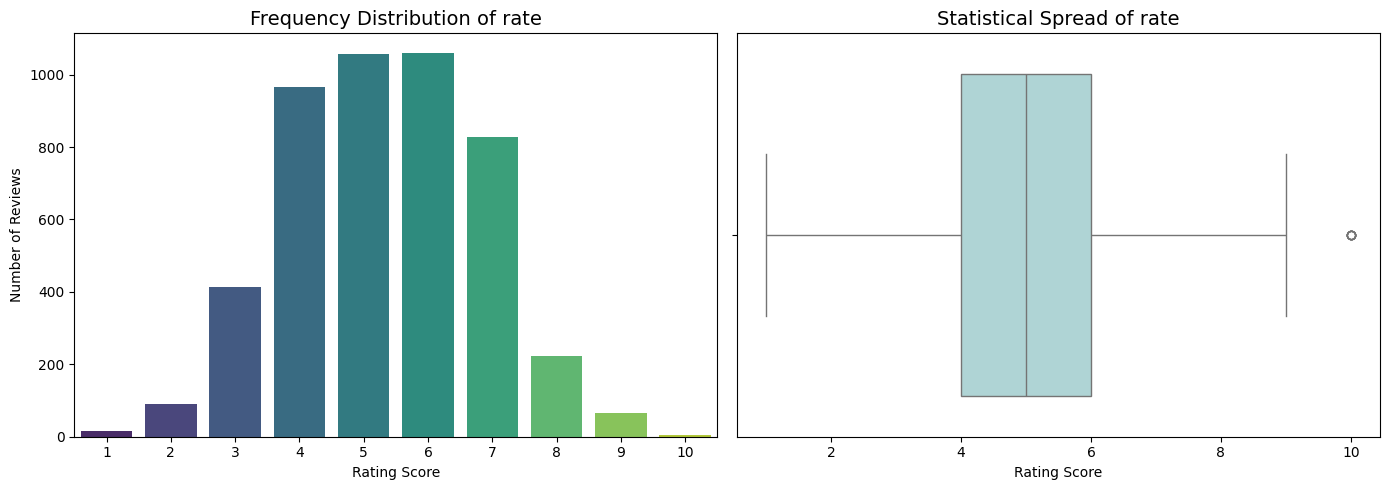

In [14]:
# Distribution of review scores
score_cols = [c for c in df.columns if "rate" in c.lower()]
if score_cols:
    for col in score_cols:
        print(f"\nScore distribution for {col}:")
        print(df[col].value_counts())
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram
        # Using a palette makes it easier to distinguish the 'Accept' vs 'Reject' zones
        sns.countplot(data=df, x=col, ax=axes[0], palette="viridis")
        axes[0].set_title(f'Frequency Distribution of {col}', fontsize=14)
        axes[0].set_xlabel('Rating Score')
        axes[0].set_ylabel('Number of Reviews')

        # Box Plot
        # This shows the median and whether your dataset is skewed toward high scores
        sns.boxplot(data=df, x=col, ax=axes[1], color="#a8dadc")
        axes[1].set_title(f'Statistical Spread of {col}', fontsize=14)
        axes[1].set_xlabel('Rating Score')

        plt.tight_layout()
        plt.savefig('Rating_distribution.png')
        plt.show()


In [15]:
# splits

train_temp = dataset.train_test_split(test_size=0.2)
val_test = train_temp['test'].train_test_split(test_size=0.5)

dataset_splits = {
    'train': train_temp['train'],
    'validation': val_test['train'],
    'test': val_test['test']
}
print("OpenReview ICLR dataset loaded and split into train, validation, and test sets.")
print(f"Train dataset size: {len(dataset_splits['train'])}")
print(f"Validation dataset size: {len(dataset_splits['validation'])}")
print(f"Test dataset size: {len(dataset_splits['test'])}")



OpenReview ICLR dataset loaded and split into train, validation, and test sets.
Train dataset size: 3779
Validation dataset size: 472
Test dataset size: 473


### 3. Preprocessing

In [16]:
# Set the max column width to None (unlimited)
pd.set_option('display.max_colwidth', None)

# Now when you show the dataframe, the full abstract will appear
df["abstract"].iloc[0]

'Probabilistic methods often need to draw samples from a nontrivial distribution. sampling is a nice algorithm by building upon a top-down construction of a Gumbel process, where a large state space is divided into subsets and at each round sampling selects a subset to process. However, the selection rule depends on a bound function, which can be intractable. Moreover, we show that such a selection criterion can be inefficient. This paper aims to improve sampling by addressing these issues. To design a suitable selection rule, we apply emph{Probability Matching}, a widely used method for decision making, to sampling. We provide insights into the relationship between sampling and probability matching by analyzing a nontrivial special case in which the state space is partitioned into two subsets. We show that in this case probability matching is optimal within a constant gap. Furthermore, as directly applying probability matching to sampling is time consuming, we design an approximate ve

In [ ]:
def standard_prompt(abstract):
    """
    Constructs the prompt string for the LLM to generate peer reviews.
    """
    return (
        "You are an expert academic peer reviewer. Your task is to provide a constructive, "
        "detailed review of a research paper based on its abstract.\n\n"

        f"Paper Abstract:\n{abstract}\n\n"

        "Instructions:\n"
        "- Analyze the research contribution, methodology, and potential impact\n"
        "- Identify specific strengths and areas for improvement\n"
        "- Provide constructive feedback that would help the authors\n"
        "- Rate the paper objectively on a 1-10 scale (1=reject, 10=accept)\n\n"

        "Required Format:\n"
        "**Strengths:**\n"
        "- [List 2-4 specific strengths]\n\n"

        "**Weaknesses:**\n"
        "- [List 2-4 specific weaknesses or areas for improvement]\n\n"

        "**Overall Assessment:**\n"
        "[2-3 sentences summarizing your overall opinion]\n\n"

        "**Rating:** [X/10]\n\n"
        "Review:"
    )

In [17]:
# def make_prompt(abstract, include_rating=True):
#     """
#     prompt structure:
#     1. Role Prompting
#     2. Few-Shot Examples (stylistic alignment)
#     3. Chain-of-Thought (Reasoning before rating)
#     4. Delimiters
#     """

#     system_context = (
#         "### INSTRUCTION\n"
#         "You are an expert Senior Reviewer for ICLR. Your task is to evaluate research abstracts "
#         "with high technical rigor. You must provide a structured review followed by a rating.\n\n"
#     )

#     # few shot example
#     few_shot_examples = (
#         "### EXAMPLES OF HIGH-QUALITY REVIEWS\n\n"
#         "Example 1 Abstract: [Probabilistic methods often need to draw samples from a nontrivial distribution. \n
#          sampling is a nice algorithm by building upon a top-down construction of a Gumbel process, \n
#           where a large state space is divided into subsets and at each round sampling selects a subset to process. \n
#           However, the selection rule depends on a bound function, which can be intractable. Moreover,\n
#            we show that such a selection criterion can be inefficient. This paper aims to improve sampling \n
#            by addressing these issues. To design a suitable selection rule, we apply emph{Probability Matching},\n
#             a widely used method for decision making, to sampling. We provide insights into the relationship \n
#             between sampling and probability matching by analyzing a nontrivial special case in which the \n
#             state space is partitioned into two subsets. We show that in this case probability matching is \n
#             optimal within a constant gap. Furthermore, as directly applying probability matching to sampling \n
#              is time consuming, we design an approximate version based on Monte-Carlo estimators. We also present \n
#               an efficient implementation by leveraging special properties of Gumbel distributions and well-designed \n
#               balanced trees. Empirical results show that our method saves a significantly amount of computational \n
#               resources on suboptimal regions compared with sampling.]\n"

#         "Example 1 Reasoning: The paper introduces interesting ideas but it's supported by poor methodology and the discussion of related work is insufficient"

#         "Example 1 Review: \n
#         It seems a good paper, containing with interesting ideas. However, \n
#         the state-of-the-art discussion about sampling methods is formed by just one sentence. \n
#         I suggest to add more references about adaptive rejection sampling and MCMC, discussing\n
#          a bit more their differences, and the differences and connections with A* sampling. \n
#          Also direct methods should be discussed. For this reasons, I also suggest to add references\n
#           to related books as Devroye*s sampling book and other, more recent books devoted to describe \n
#           independent random sampling methods."

#         "STRENGTHS:\n"
#         "- Novel approach\n"
#         "WEAKNESSES:\n"
#         "- Poor methodology.\n"
#         "RATING: 6 \n"
#         "---\n\n"
#     )

#     # CoT by explicitly asking to reason
#     task_input = (
#         "### CURRENT TASK\n"
#         f"Abstract to evaluate: '''\n{abstract}\n'''\n\n"
#         "### STEP-BY-STEP EVALUATION PROCESS\n"
#         "1. Identify the core contribution (Novelty).\n"
#         "2. Detect any methodological gaps or lack of clarity.\n"
#         "3. Synthesize these points into a balanced review.\n"
#         "4. Assign a final rating that strictly matches the sentiment of your text.\n\n"
#     )

#     # note: output could anyway be violated, must be enforced outside with appropriate library (e.g: pydantic)
#     output_format = (
#         "### YOUR RESPONSE\n"
#         "REASONING: [Briefly analyze the abstract here first]\n\n"
#         "STRENGTHS:\n"
#         "- \n\n"
#         "WEAKNESSES:\n"
#         "- \n\n"
#         "OVERALL ASSESSMENT:\n"
#         "\n\n"
#     )

#     if include_rating:
#         output_format += "RATING: [X/10]"

#     return system_context + few_shot_examples + task_input + output_format

In [18]:
# note: i know args hardcoded like this is not a best practice
def make_prompt(abstract, ex_abstract=df["abstract"].iloc[0], ex_review=df["review"].iloc[0], ex_rating=df["rate"].iloc[0], include_rating=True):
    """
    prompt structure:
    1. Role Prompting
    2. Few-Shot Examples (stylistic alignment)
    3. Chain-of-Thought (Reasoning before rating)
    4. Delimiters
    """

    system_context = (
        "### INSTRUCTION\n"
        "You are an expert Senior Reviewer for ICLR. Your task is to evaluate research abstracts "
        "with high technical rigor. You must provide a structured review followed by a rating.\n\n"
    )

    # few shot example
    few_shot_examples = (
        f"""### EXAMPLES OF HIGH-QUALITY REVIEWS
        Example 1 Abstract: '''{ex_abstract}'''

        "Example 1 Reasoning: The paper introduces interesting ideas but it's supported by poor methodology and the discussion of related work is insufficient"

        "Example 1 Review: {ex_review}\n"

        "STRENGTHS:\n"
        "- Novel approach\n"
        "WEAKNESSES:\n"
        "- Poor methodology.\n"
        "RATING: {ex_rating} \n"
        "---\n\n"
    )"""

    # CoT by explicitly asking to reason
    task_input = (
        "### CURRENT TASK\n"
        f"Abstract to evaluate: '''\n{abstract}\n'''\n\n"
        "### STEP-BY-STEP EVALUATION PROCESS\n"
        "1. Identify the core contribution (Novelty).\n"
        "2. Detect any methodological gaps or lack of clarity.\n"
        "3. Synthesize these points into a balanced review.\n"
        "4. Assign a final rating (1-10) that strictly matches the sentiment of your text.\n"
    )

    # note: output could anyway be violated, must be enforced outside with appropriate library (e.g: pydantic)
    output_format = (
        "### YOUR RESPONSE\n"
        "REASONING: [Briefly analyze the abstract here first]\n\n"
        "STRENGTHS:\n"
        "- \n\n"
        "WEAKNESSES:\n"
        "- \n\n"
        "OVERALL ASSESSMENT:\n"
        "\n\n"
    )

    if include_rating:
        output_format += "RATING: [X/10]"

    return system_context + few_shot_examples + task_input + output_format

In [19]:
def preprocess_batch(batch):
    """
    Tokenizes the input and masks the prompt tokens in the labels.
    This ensures the model only trains on generating the review text.
    It uses the 'abstract' column for the prompt and the 'review' for the target.
    """
    MAX_LEN = 512
    prompts = [make_prompt(a) for a in batch["abstract"]]
    targets = batch["review"]

    # Add EOS token to targets to teach the model when to stop
    eos_token = tokenizer.eos_token if tokenizer.eos_token else "</s>"
    targets_with_eos = [t + eos_token for t in targets]

    # Tokenize prompts to get their lengths
    prompt_tok = tokenizer(prompts, add_special_tokens=False, truncation=True)

    # Tokenize full (prompt + target + EOS) with fixed length
    full_texts = [p + t for p, t in zip(prompts, targets_with_eos)]
    full_tok = tokenizer(
        full_texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True  # Ensure special tokens are added
    )

    labels = []
    for ids, p_len in zip(full_tok["input_ids"], [len(x) for x in prompt_tok["input_ids"]]):
        lab = ids.copy()
        # mask prompt tokens
        for i in range(min(p_len, len(lab))):
            lab[i] = -100

        for i, token_id in enumerate(lab):
            if token_id == tokenizer.pad_token_id:
                lab[i] = -100

        labels.append(lab)

    full_tok["labels"] = labels
    return full_tok

In [20]:
# Define the quantization configuration for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_name = "Qwen/Qwen3-1.7B"

In [21]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load the base model with quantization
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
# base_model.to(device) not needed

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### 4. Evaluation settings

In [39]:
def evaluate_rating_prediction(model):
    """
    Evaluates the model and computes the mean squared error (MSE) based on a crude
    parse of the model's output.
    """
    preds, labels = [], []
    for ex in tqdm(dataset_splits["test"]):
        # Prepare input for the model. We'll add the "Review Score:" prompt
        # to get a numerical output for the regression metric.
        inp = tokenizer(f"Paper abstract: {ex['abstract']}\nReview Score:", return_tensors="pt").to(model.device)
        # Generate a short output to predict the score
        out = model.generate(**inp, max_new_tokens=5)
        pred_text = tokenizer.decode(out[0], skip_special_tokens=True)

        # Crude attempt to parse a score from the output text
        try:
            pred_score = float(pred_text.split()[-1])
        except:
            pred_score = 0

        preds.append(pred_score)
        labels.append(ex["rate"])

    return mean_squared_error(preds, labels), mean_absolute_error(preds, labels)

# a more advanced approach to find the rate, which could solve the limitation related to assign the correct rate
# requires further testing
#the evaluation requires much more time
def _evaluate_rating_prediction(model, tokenizer, dataset_splits):
    preds, labels = [], []
    parse_errors = 0

    for ex in tqdm(dataset_splits["test"]):
        prompt = f"Abstract: {ex['abstract']}\nReview:"
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        # Generate the full review and rating
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False  # For deterministic output
        )
        generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        # This regex looks for "rate:", followed by any characters, then a number
        match = re.search(r'rate:.*?(\d+)', generated_text, re.IGNORECASE)

        if match:
            try:
                pred_score = int(match.group(1))
                preds.append(pred_score)
                labels.append(ex["rate"])
            except (ValueError, IndexError):
                parse_errors += 1
        else:
            parse_errors += 1

    if not preds:
        return float('inf'), float('inf')

    mse = mean_squared_error(preds, labels)
    mae = mean_absolute_error(preds, labels)

    print(f"Total samples: {len(dataset_splits['test'])}")
    print(f"Successfully parsed predictions: {len(preds)}")
    print(f"Parsing errors: {parse_errors}")

    return mse, mae

def evaluate_text_generation(model):
    """
    Evaluates the model's ability to generate coherent reviews using ROUGE, BERTScore,
    and Perplexity on a random 10% subset of the test data. Results are stored in a DataFrame.
    """
    # Initialize the ROUGE scorer
    scorer = RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    predictions = []
    references = []
    abstracts = []

    # Perplexity tracking variables
    total_loss = 0
    total_tokens = 0

    # Create a random 10% subset of the test set for evaluation
    num_subset_examples = int(len(dataset_splits["test"]) * 0.1) # subset can be lower to allow quick debugging, but report results are obtained with 10%
    test_subset = dataset_splits["test"].shuffle(seed=77).select(range(num_subset_examples))

    print(f"Starting text generation evaluation on a random subset of {len(test_subset)} examples...")

    model.eval()

    # Generate predictions and calculate perplexity
    for ex in tqdm(test_subset, desc="Evaluating Text Generation + Perplexity"):
        prompt = make_prompt(ex["abstract"])
        target_review = ex["review"]
        full_text = prompt + target_review

        with torch.no_grad():
            full_inputs = tokenizer(
                full_text,
                return_tensors="pt",
                max_length=512,
                truncation=True
            ).to(model.device)

            prompt_inputs = tokenizer(
                prompt,
                return_tensors="pt",
                max_length=512,
                truncation=True
            ).to(model.device)

            # Calculate loss for perplexity
            outputs = model(**full_inputs, labels=full_inputs["input_ids"])
            loss = outputs.loss.item()

            # Calculate number of target tokens
            prompt_length = prompt_inputs["input_ids"].shape[1]
            full_length = full_inputs["input_ids"].shape[1]
            target_length = full_length - prompt_length

            # Accumulate loss and tokens for perplexity calculation
            if target_length > 0:
                total_loss += loss * target_length
                total_tokens += target_length

            # Text Generation for ROUGE/BERTScore
            # Generate new text for evaluation
            generation_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            generation_outputs = model.generate(
                **generation_inputs,
                max_new_tokens=150,
                do_sample=True,
                top_k=50,
                temperature=0.7,
                pad_token_id=tokenizer.eos_token_id,
            )

            generated_review = tokenizer.decode(generation_outputs[0], skip_special_tokens=True)
            clean_generated_review = generated_review.replace(prompt, "").strip()

        predictions.append(clean_generated_review)
        references.append(ex["review"])
        abstracts.append(ex["abstract"])

    # Calculate Perplexity
    if total_tokens > 0:
        avg_loss = total_loss / total_tokens
        perplexity = torch.exp(torch.tensor(avg_loss)).item()
    else:
        perplexity = float('inf')

    print(f"Calculated Perplexity: {perplexity:.2f}")

    # ROUGE calculation
    rouge_results = {
        'rouge1': {'fmeasure': 0.0, 'precision': 0.0, 'recall': 0.0},
        'rouge2': {'fmeasure': 0.0, 'precision': 0.0, 'recall': 0.0},
        'rougeL': {'fmeasure': 0.0, 'precision': 0.0, 'recall': 0.0}
    }

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        for metric in rouge_results:
            rouge_results[metric]['fmeasure'] += getattr(scores[metric], "fmeasure", 0.0)
            rouge_results[metric]['precision'] += getattr(scores[metric], "precision", 0.0)
            rouge_results[metric]['recall'] += getattr(scores[metric], "recall", 0.0)

    # Average ROUGE scores
    num_samples = len(predictions)
    for metric in rouge_results:
        for score_type in ['fmeasure', 'precision', 'recall']:
            rouge_results[metric][score_type] /= num_samples

    # BERTScore calculation
    predictions_clean = [p.replace("**Strengths:**", "").strip() for p in predictions]
    references_clean = [r.replace("**Strengths:**", "").strip() for r in references]
    P, R, F1 = bert_score(predictions_clean, references_clean, model_type="roberta-large", lang="en")

    bert_results = {
        "precision": float(P.mean()),
        "recall": float(R.mean()),
        "f1": float(F1.mean())
    }

    # Perplexity results
    perplexity_results = {
        "perplexity": perplexity
    }

    # Results
    df = pd.DataFrame({
        "Abstract": abstracts,
        "GroundTruth": references,
        "Generated": predictions
    })

    df["BERTScore_F1"] = F1.tolist()

    print("\n" + "="*50)
    print("EVALUATION RESULTS SUMMARY")
    print("="*50)
    print(f"Perplexity: {perplexity:.2f}")
    print(f"ROUGE-1 F1: {rouge_results['rouge1']['fmeasure']:.4f}")
    print(f"ROUGE-2 F1: {rouge_results['rouge2']['fmeasure']:.4f}")
    print(f"ROUGE-L F1: {rouge_results['rougeL']['fmeasure']:.4f}")
    print(f"BERTScore F1: {bert_results['f1']:.4f}")
    print("="*50)

    return rouge_results, bert_results, perplexity_results, df

### 5. Zero shot results

In [40]:
# rating prediction, how well the model assign rate in zero shot
zero_shot_performance = evaluate_rating_prediction(base_model)

print(f"Rating MSE, MAE: {zero_shot_performance}")


100%|██████████| 473/473 [04:26<00:00,  1.77it/s]

Rating MSE, MAE: (30.9561310782241, 5.324524312896406)


In [41]:
# zero shot evaluation
zero_shot_rouge_performance = evaluate_text_generation(base_model)
print(f"ROUGE scores: {zero_shot_rouge_performance}")

Starting text generation evaluation on a random subset of 47 examples...


Evaluating Text Generation + Perplexity: 100%|██████████| 47/47 [12:29<00:00, 15.96s/it]


Calculated Perplexity: inf


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



EVALUATION RESULTS SUMMARY
Perplexity: inf
ROUGE-1 F1: 0.2640
ROUGE-2 F1: 0.0452
ROUGE-L F1: 0.1378
BERTScore F1: 0.8232
ROUGE scores: ({'rouge1': {'fmeasure': 0.263953567332417, 'precision': 0.5440186312405166, 'recall': 0.18693341168781305}, 'rouge2': {'fmeasure': 0.04520929116667859, 'precision': 0.09916629088907299, 'recall': 0.031456532559242786}, 'rougeL': {'fmeasure': 0.13778022451665306, 'precision': 0.2876278217627677, 'recall': 0.09742050054859543}}, {'precision': 0.8349359631538391, 'recall': 0.8119938373565674, 'f1': 0.8232460618019104}, {'perplexity': inf},                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [42]:
# zero shot results
rouge1 = zero_shot_rouge_performance[0]['rouge1']
rouge2 = zero_shot_rouge_performance[0]['rouge2']
rougeL = zero_shot_rouge_performance[0]['rougeL']
bertscore = zero_shot_rouge_performance[1]
perplexity = zero_shot_rouge_performance[2]['perplexity']

metrics = pd.DataFrame([
    {"Metric": "ROUGE-1", "F1": rouge1['fmeasure'], "Precision": rouge1['precision'], "Recall": rouge1['recall']},
    {"Metric": "ROUGE-2", "F1": rouge2['fmeasure'], "Precision": rouge2['precision'], "Recall": rouge2['recall']},
    {"Metric": "ROUGE-L", "F1": rougeL['fmeasure'], "Precision": rougeL['precision'], "Recall": rougeL['recall']},
    {"Metric": "BERTScore", "F1": bertscore['f1'], "Precision": bertscore['precision'], "Recall": bertscore['recall']},
])

metrics

,Metric,F1,Precision,Recall
0,ROUGE-1,0.263954,0.544019,0.186933
1,ROUGE-2,0.045209,0.099166,0.031457
2,ROUGE-L,0.137780,0.287628,0.097421
3,BERTScore,0.823246,0.834936,0.811994


### 6. Training settings and debugging

In [43]:
# This step is required for quantized models before applying LoRA
base_model = prepare_model_for_kbit_training(base_model)

for param in base_model.parameters():
    param.requires_grad = False

# Apply the LoRA configuration on top of the quantized model
config = LoraConfig(
    r=8, # standard combination of r-alpha
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"], # "k_proj" and "o_proj" can be added but training time increases
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(base_model, config)

# Print a summary of the trainable parameters to confirm LoRA is active
model.print_trainable_parameters()

trainable params: 1,605,632 || all params: 2,033,345,536 || trainable%: 0.0790


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [44]:
# CRITICAL DEBUG: Check what's actually trainable
print("Detailed Parameter Check")
trainable_params = []
non_trainable_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append((name, param.numel()))
    else:
        non_trainable_params.append((name, param.numel()))

print(f"\nSummary:")
print(f"Trainable parameters: {len(trainable_params)}")
print(f"Non-trainable parameters: {len(non_trainable_params)}")

if len(trainable_params) == 0:
    print("Error: no trainable parameters found")

    # Try to fix by enabling LoRA parameters
    print("Attempting to enable LoRA parameters...")
    for name, param in model.named_parameters():
        if 'lora' in name.lower():
            param.requires_grad = True
            print(f"Enabled: {name}")

print("Setting Training Mode")
model.train()
print(f"Model training mode: {model.training}")

Detailed Parameter Check

Summary:
Trainable parameters: 112
Non-trainable parameters: 311
Setting Training Mode
Model training mode: True


In [45]:
# Verify the model is in training mode and has trainable parameters
#model.train()

# Preprocess the splits
tokenized_train = dataset_splits["train"].map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset_splits["train"].column_names)

tokenized_validation = dataset_splits["validation"].map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset_splits["validation"].column_names)

tokenized_test = dataset_splits["test"].map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset_splits["test"].column_names)

# Define the data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False, pad_to_multiple_of=8)

Map:   0%|          | 0/3779 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/473 [00:00<?, ? examples/s]

In [29]:
# could be useful to avoid OOM error
#torch.cuda.empty_cache()

In [46]:
# Custom Callback for Plotting
class PlottingCallback(TrainerCallback):
    """
    A custom callback to log and plot training and validation loss using.
    """
    def __init__(self):
        self.training_losses = []
        self.validation_losses = []
        self.training_epochs = []
        self.validation_epochs = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        """
        This method is called at each logging step.
        """
        if logs is None:
            return

        print(f"Logging at step {state.global_step}, epoch {state.epoch}")
        print(f"Available logs: {logs.keys()}")

        # Log the training loss
        if 'loss' in logs:
            print(f"Training loss: {logs['loss']}")
            self.training_losses.append(logs['loss'])
            self.training_epochs.append(state.epoch)

        # Log the validation loss
        if 'eval_loss' in logs:
            print(f"Validation loss: {logs['eval_loss']}")
            self.validation_losses.append(logs['eval_loss'])
            self.validation_epochs.append(state.epoch)

    def on_evaluate(self, args, state, control, logs=None, **kwargs):
        """
        Called after evaluation. Sometimes eval_loss appears here instead of on_log.
        """
        if logs is None:
            return

        print(f"Evaluation at epoch {state.epoch}")
        print(f"Eval logs: {logs.keys()}")

        if 'eval_loss' in logs:
            print(f"Evaluation loss: {logs['eval_loss']}")
            # Avoid duplicates
            if not self.validation_epochs or self.validation_epochs[-1] != state.epoch:
                self.validation_losses.append(logs['eval_loss'])
                self.validation_epochs.append(state.epoch)

    def on_train_end(self, args, state, control, **kwargs):
        """
        This method is called when the training is complete.
        """
        print(f"Training ended. Training losses: {len(self.training_losses)}, Validation losses: {len(self.validation_losses)}")

        if not self.training_losses and not self.validation_losses:
            print("No losses recorded! Check your logging configuration.")
            return

        # Create a Plotly figure
        fig = go.Figure()

        # Add training loss trace
        if self.training_losses:
            fig.add_trace(go.Scatter(
                x=self.training_epochs,
                y=self.training_losses,
                mode='lines+markers',
                name='Training Loss',
                line=dict(color='blue')
            ))

        # Add validation loss trace
        if self.validation_losses:
            fig.add_trace(go.Scatter(
                x=self.validation_epochs,
                y=self.validation_losses,
                mode='lines+markers',
                name='Validation Loss',
                line=dict(color='red')
            ))

        fig.update_layout(
            title='Training and Validation Loss over Epochs',
            xaxis_title='Epoch',
            yaxis_title='Loss',
            legend_title='Metrics',
            width=800,
            height=600
        )

        # Save the plot as an HTML file in the results directory
        #output_path = os.path.join(args.output_dir, "loss_plot.html")
        #os.makedirs(args.output_dir, exist_ok=True)
        #pio.write_html(fig, file=output_path, auto_open=False)
        #print(f"Loss plot saved to: {output_path}")

        # Also show the plot if in a notebook environment
        try:
            fig.show()
        except Exception as e:
            print(f"Could not display plot: {e}")

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=10,
    logging_steps=100,  # modify for more or less frequent logging
    eval_strategy="steps",  # Change from "epoch" to "steps" for more frequent eval
    eval_steps=100,
    save_strategy="steps", # must coincide to eval_strategy
    save_steps=500,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    fp16=True,
    learning_rate=5e-4,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs",
    report_to=["tensorboard"],
    logging_first_step=True,
    gradient_checkpointing=False,
)
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), PlottingCallback()]
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [47]:
# debugging: test forward pass before training
# very useful to immediately spot issues in the forward pass
print("Testing Forward Pass")
try:
    # Get a small batch for testing
    test_batch = next(iter(trainer.get_train_dataloader()))
    print(f"Test batch keys: {test_batch.keys()}")
    print(f"Input shape: {test_batch['input_ids'].shape}")

    # Test forward pass
    model.eval()  # Temporarily set to eval for testing
    with torch.no_grad():
        outputs = model(**test_batch)
        print("Forward pass successful")
        print(f"Loss shape: {outputs.loss.shape if hasattr(outputs, 'loss') else 'No loss'}")

    # Back to training mode
    model.train()

    # Test if loss requires grad
    outputs = model(**test_batch)
    if hasattr(outputs, 'loss'):
        print(f"Loss requires_grad: {outputs.loss.requires_grad}")
        if outputs.loss.requires_grad:
            print("Loss tensor is ready for backpropagation")
        else:
            print("Loss tensor does not require gradients!")
    else:
        print("No loss in model outputs!")

except Exception as e:
    print(f"Forward pass failed: {e}")
    print("This indicates a problem with the model or data.")

Testing Forward Pass


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Test batch keys: KeysView({'input_ids': tensor([[14374,  1964, 57455,  ...,  5306, 43613,   323],
        [14374,  1964, 57455,  ...,    26,  9926,   306],
        [14374,  1964, 57455,  ...,   646,  1221,   990],
        [14374,  1964, 57455,  ...,     8, 11508,   311]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'labels': tensor([[14374,  1964, 57455,  ...,  5306, 43613,   323],
        [14374,  1964, 57455,  ...,    26,  9926,   306],
        [14374,  1964, 57455,  ...,   646,  1221,   990],
        [14374,  1964, 57455,  ...,     8, 11508,   311]], device='cuda:0')})
Input shape: torch.Size([4, 512])
Forward pass successful
Loss shape: torch.Size([])


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Loss requires_grad: True
Loss tensor is ready for backpropagation


In [48]:
print("Final Check Before Training")
total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
if total_trainable == 0:
    print("CRITICAL: Still no trainable parameters!")
    print("Manually enabling all LoRA parameters...")

    # Force enable LoRA parameters
    for name, module in model.named_modules():
        if hasattr(module, 'lora_A') or hasattr(module, 'lora_B'):
            for param in module.parameters():
                param.requires_grad = True
                print(f"Force enabled: {name}")
else:
    print(f"Found {total_trainable:,} trainable parameters")

Final Check Before Training
Found 1,605,632 trainable parameters


In [49]:
# Start training with error handling
print("Starting fine-tuning")
trainer.train()
# additional debugging if needed
#try:
#    trainer.train()
#except RuntimeError as e:
#    print(f"Training failed with error: {e}")

#    print("\n Additional Debugging")
 #   print("Checking model state:")
#    print(f"Model device: {next(model.parameters()).device}")
#    print(f"Model dtype: {next(model.parameters()).dtype}")

    # Check if it's a device mismatch
 #   sample_batch = next(iter(trainer.get_train_dataloader()))
 #   print(f"Input device: {sample_batch['input_ids'].device}")
 #   print(f"Input dtype: {sample_batch['input_ids'].dtype}")

 #   raise e

Starting fine-tuning


Step,Training Loss,Validation Loss


Logging at step 1, epoch 0.008465608465608466
Available logs: dict_keys(['loss', 'grad_norm', 'learning_rate', 'epoch'])
Training loss: 3.436079740524292


KeyboardInterrupt: 

### 7. QLoRa results

In [ ]:
# evaluate rate assignment
print(" Starting fine-tuned model evaluation ")
fine_tuned_performance = evaluate_rating_prediction(model)
print("QLoRA fine-tuned model performance:", fine_tuned_performance)

In [ ]:
# QLoRa evaluation
fine_tuned_rouge_performance = evaluate_text_generation(model)
print(f"ROUGE scores: {fine_tuned_rouge_performance}")

In [ ]:
# QLoRa results
rouge1 = fine_tuned_rouge_performance[0]['rouge1']
rouge2 = fine_tuned_rouge_performance[0]['rouge2']
rougeL = fine_tuned_rouge_performance[0]['rougeL']
bertscore = fine_tuned_rouge_performance[1]

metrics = pd.DataFrame([
    {"Metric": "ROUGE-1", "F1": rouge1['fmeasure'], "Precision": rouge1['precision'], "Recall": rouge1['recall']},
    {"Metric": "ROUGE-2", "F1": rouge2['fmeasure'], "Precision": rouge2['precision'], "Recall": rouge2['recall']},
    {"Metric": "ROUGE-L", "F1": rougeL['fmeasure'], "Precision": rougeL['precision'], "Recall": rougeL['recall']},
    {"Metric": "BERTScore", "F1": bertscore['f1'], "Precision": bertscore['precision'], "Recall": bertscore['recall']}
])

metrics

### 8. Review Sample generation

In [ ]:
# Display generated vs. human reviews
def display_generated_reviews(model, dataset):
    """
    Generates and displays reviews for a few examples from the test dataset.
    This provides a qualitative check on the model's performance.
    """
    print("\nDisplaying Generated Reviews")

    # Take a small sample of the test dataset
    for i, ex in enumerate(dataset.select(range(5, 8))):
        print(f"\n--- Example {i+1} ---")

        # Original Paper Abstract
        print("Paper Abstract:")
        print(ex["abstract"])

        # Ground-Truth Review
        print("\nGround-Truth Review:")
        print(ex["review"])

        # Generate a new review using the fine-tuned model
        prompt = make_prompt(ex["abstract"])
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        # Configure generation parameters for more varied output
        outputs = model.generate(
            **inputs,
            max_new_tokens=300, # Set a reasonable limit for the review length
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        generated_review = tokenizer.decode(outputs[0], skip_special_tokens=True)

        generated_review = generated_review.replace(prompt, "")
        print("\nGenerated Review:")
        print(generated_review.strip())

In [ ]:
# Display reviews for the zero shot model
display_generated_reviews(base_model, dataset_splits["test"])

In [ ]:
# Display reviews for the fine tuned model
display_generated_reviews(model, dataset_splits["test"])